In [23]:
import pandas as pd
df = pd.read_csv("/Users/annu/Desktop/Financial Misinformation Detection with LLM Hallucination Auditing + Market Impact Analysis/data/headlines_verified.csv")
print(df['related_stock'].unique())

['ADANIENT' 'RELIANCE' 'HDFCBANK' 'INFY' 'TCS' 'HCLTECH' 'WIPRO'
 'TATAMOTORS' 'MARUTI' 'ICICIBANK' 'PAYTM' 'ZOMATO' 'NYKAA' 'LICI'
 'BHARTIARTL' 'TATASTEEL' 'SUNPHARMA' 'DRREDDY' 'SENSEX' 'NIFTYBANK'
 'INDIGO' 'HINDUNILVR' 'DELHIVERY' 'BAJFINANCE' 'BITCOIN' 'LUNA' 'FTX'
 'WAZIRX' 'ONGC' 'ASIANPAINT' 'CIPLA' 'POLICYBZR' 'SWIGGY' 'IDEA'
 'BAJAJAUTO' 'DIXON']


In [24]:
import yfinance as yf

ticker_map = {
    'ADANIENT': 'ADANIENT.NS','RELIANCE': 'RELIANCE.NS',
    'HDFCBANK': 'HDFCBANK.NS','BITCOIN': 'BTC-USD',
    'SENSEX': '^BSESN','INFY':'INFY.NS',
    'TCS':'TCS.NS','HCLTECH': 'HCLTECH.NS',
    'WIPRO':'WIPRO.NS','TATAMOTORS':'TATAMOTORS.NS',
    'MARUTI':'MARUTI.NS', 'ICICIBANK':'ICICIBANK.NS',
    'PAYTM':'PAYTM.NS', 'ZOMATO':'ZOMATO.NS', 
    'NYKAA':'NYKAA.NS', 'LICI':'LICI.NS',
    'BHARTIARTL':'BHARTIARTL.NS', 'TATASTEEL':'TATASTEEL.NS',
    'SUNPHARMA':'SUNPHARMA.NS', 'DRREDDY':'DRREDDY.NS',
    'NIFTYBANK':'^NSEBANK','INDIGO': 'INDIGO.NS','HINDUNILVR':'HINDUNILVR.NS', 
    'DELHIVERY':'DELHIVERY.NS', 'BAJFINANCE':'BAJFINANCE.NS', 
    'LUNA': None, 'FTX': None,
    'WAZIRX': None, 'ONGC':'ONGC.NS',
    'ASIANPAINT':'ASIANPAINT.NS', 'CIPLA':'CIPLA.NS', 
    'POLICYBZR':'POLICYBZR.NS', 'SWIGGY': None,
    'IDEA':'IDEA.NS','BAJAJAUTO':'BAJAJ-AUTO.NS', 'DIXON':'DIXON.NS'
}

#downloading price for tickers
price_data = {} #dictionary with key as ticker and value as yf stock price dataset
for ticker , yf_ticker in ticker_map.items():
    if yf_ticker is None:
        print(f"skipping {ticker} - no data available")
        continue
    try:
        data = yf.download(yf_ticker, start='2021-01-01', end='2024-12-31')
        if data.empty:
            print(f"No data for {ticker} - skipping")
        else:
            price_data[ticker] = data #this data is a df so in dictonary tha values are also in form of df
    except Exception as e:
        print(f"Failed {ticker}: {e}")

print(price_data['ADANIENT'].head())
print(price_data['ADANIENT'].shape)

print("Successfully downloaded:", list(price_data.keys())) #only these tickers data is available on yfinance
print("Total tickers:", len(price_data))


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
$TATAMOTORS.NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found


No data for TATAMOTORS - skipping


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
$ZOMATO.NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ZOMATO.NS']: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************] 

No data for ZOMATO - skipping


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


skipping LUNA - no data available
skipping FTX - no data available
skipping WAZIRX - no data available


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


skipping SWIGGY - no data available
Price            Close        High         Low        Open      Volume
Ticker     ADANIENT.NS ADANIENT.NS ADANIENT.NS ADANIENT.NS ADANIENT.NS
Date                                                                  
2021-01-01  489.959900  492.054818  475.844193  475.844193     5035248
2021-01-04  493.301758  501.382136  485.470773  490.807816     4936582
2021-01-05  493.201965  500.185003  488.413609  490.807787     3654033
2021-01-06  489.710480  499.436854  483.076600  494.798128     3295461
2021-01-07  516.844482  522.680343  492.603380  492.703144     9879731
(986, 5)
Successfully downloaded: ['ADANIENT', 'RELIANCE', 'HDFCBANK', 'BITCOIN', 'SENSEX', 'INFY', 'TCS', 'HCLTECH', 'WIPRO', 'MARUTI', 'ICICIBANK', 'PAYTM', 'NYKAA', 'LICI', 'BHARTIARTL', 'TATASTEEL', 'SUNPHARMA', 'DRREDDY', 'NIFTYBANK', 'INDIGO', 'HINDUNILVR', 'DELHIVERY', 'BAJFINANCE', 'ONGC', 'ASIANPAINT', 'CIPLA', 'POLICYBZR', 'IDEA', 'BAJAJAUTO', 'DIXON']
Total tickers: 30


In [25]:
# Downloading NIFTY 50 as market benchmark
# ^NSEI is the yfinance ticker for NIFTY 50

nifty_df = yf.download(tickers='^NSEI', start='2021-01-01', end='2024-12-31') #also called nifty return(per day)
if nifty_df.empty:
    print("NIFTY data download failed")
else:
    print("nifty50 downloaded successfull")
    print(nifty_df.shape)
    print(nifty_df.head())

#built in funtion for calculating percent change for each row with preceding row
pct_return_data = {} #key as ticker and value are percent change per day
for ticker, data in price_data.items():
    pct_return_data[ticker] = data['Close'].squeeze().pct_change() #called stock return(per day), percent change of close cloumn


nifty_pct_change = nifty_df['Close'].squeeze().pct_change()

print(type(pct_return_data['ADANIENT']))
print(pct_return_data['ADANIENT'].head())


[*********************100%***********************]  1 of 1 completed

nifty50 downloaded successfull
(986, 5)
Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2021-01-01  14018.500000  14049.849609  13991.349609  13996.099609  358100
2021-01-04  14132.900391  14147.950195  13953.750000  14104.349609  495000
2021-01-05  14199.500000  14215.599609  14048.150391  14075.150391  492500
2021-01-06  14146.250000  14244.150391  14039.900391  14240.950195  632300
2021-01-07  14137.349609  14256.250000  14123.099609  14253.750000  559200
<class 'pandas.core.series.Series'>
Date
2021-01-01         NaN
2021-01-04    0.006821
2021-01-05   -0.000202
2021-01-06   -0.007079
2021-01-07    0.055408
Name: ADANIENT.NS, dtype: float64


In [26]:
#coverting data column in datatime format
df = pd.read_csv('/Users/annu/Desktop/Financial Misinformation Detection with LLM Hallucination Auditing + Market Impact Analysis/headlines_layer2.csv')
df["date"]=pd.to_datetime(df.date)

In [27]:
import statsmodels.api as sm
from scipy import stats
results = []

for index, row in df.iterrows():
    end = row['date']
    start = row['date'] - pd.DateOffset(days = 60 )
    yf_ticker = row['related_stock']
    if row['related_stock'] not in pct_return_data:
        continue
    stock_return = pct_return_data[yf_ticker].loc[start:end] #stock return for 60 days estimation window
    if len(stock_return) < 30: #incase i dont have data
        continue
    nifty_return = nifty_pct_change.loc[start:end] #nifty return for 60 days estimation window

    aligned = pd.concat([stock_return, nifty_return ], axis=1).dropna()
    X = aligned.iloc[:, 1]  # NIFTY returns (independent variable)
    y = aligned.iloc[:, 0]  # Stock returns (dependent variable)
    #Stock Return = α × 1 + β × NIFTY Return
    X = sm.add_constant(X) #1
    model = sm.OLS(y, X).fit()
    alpha = model.params.iloc[0]
    beta = model.params.iloc[1]

    #event window
    ev_start = row['date'] - pd.DateOffset(days = 5)
    ev_end = row['date'] + pd.DateOffset(days=10)

    stock_return_2 = pct_return_data[yf_ticker].loc[ev_start:ev_end]# actual stock return for 15 days event window
    nifty_return_2 = nifty_pct_change.loc[ev_start:ev_end] #nifty return for 15 days event window

    #predicted values in event window
    expected_returns = alpha + beta*nifty_return_2 #nifty_return_2 is already a series so we dont need loop

    abnormal_return =  stock_return_2 - expected_returns
    t_stat, p_value = stats.ttest_1samp(abnormal_return.dropna(), 0)
    CAR = abnormal_return.sum()
    print(f"CAR: {CAR}, stock_return_2 length: {len(stock_return_2)}, expected length: {len(expected_returns)}")

    results.append({
    'date': row['date'],
    'ticker': row['related_stock'],
    'CAR': CAR,
    't-statistic': round(t_stat,4),
    'p_value': round(p_value,4),
    'is significant' : 1 if p_value<0.05 else 0
    })

results_df = pd.DataFrame(results)
df_layer3 = df.merge(results_df, left_on=['date', 'related_stock'], right_on=['date', 'ticker'])
df_layer3.to_csv('headlines_layer3.csv', index=False)






    

CAR: -0.6511665846536823, stock_return_2 length: 11, expected length: 11
CAR: -0.24179394584214262, stock_return_2 length: 11, expected length: 11
CAR: -0.3708536900689189, stock_return_2 length: 11, expected length: 11
CAR: -0.3616720149821913, stock_return_2 length: 11, expected length: 11
CAR: -0.2076453813535758, stock_return_2 length: 11, expected length: 11
CAR: 0.5190257461098048, stock_return_2 length: 9, expected length: 9
CAR: -0.01866622436550702, stock_return_2 length: 11, expected length: 11
CAR: -0.01866622436550702, stock_return_2 length: 11, expected length: 11
CAR: -0.14514072778986903, stock_return_2 length: 9, expected length: 9
CAR: -0.015617812929077681, stock_return_2 length: 11, expected length: 11
CAR: -0.01376534579310616, stock_return_2 length: 11, expected length: 11
CAR: -0.03999776100551306, stock_return_2 length: 11, expected length: 11
CAR: -0.12807862932949968, stock_return_2 length: 10, expected length: 10
CAR: -0.11110692864226292, stock_return_2 lengt

In [28]:
print(df_layer3.shape)
print(df_layer3[['date', 'related_stock', 'CAR']].head(10))
print(f"Headlines processed: {len(df_layer3)}")

(59, 21)
        date related_stock       CAR
0 2023-01-24      ADANIENT -0.651167
1 2023-01-29      ADANIENT -0.241794
2 2023-01-30      ADANIENT -0.370854
3 2023-02-01      ADANIENT -0.361672
4 2023-02-03      ADANIENT -0.207645
5 2023-03-02      ADANIENT  0.519026
6 2024-08-12      ADANIENT -0.018666
7 2024-08-12      ADANIENT -0.018666
8 2024-08-12      ADANIENT -0.018666
9 2024-08-12      ADANIENT -0.018666
Headlines processed: 59


In [29]:
print(df_layer3[['headline', 'related_stock', 'CAR']].head(10))
print(df_layer3['CAR'].describe())
print(df_layer3['CAR'].isna().sum(), "headlines with no CAR data")

                                            headline related_stock       CAR
0  Hindenburg Research accuses Adani Group of bra...      ADANIENT -0.651167
1  Adani Group calls Hindenburg report a calculat...      ADANIENT -0.241794
2  Adani Group loses more than 68 billion dollars...      ADANIENT -0.370854
3  Adani Enterprises abandons 2.5 billion dollar ...      ADANIENT -0.361672
4  Adani Enterprises shares fall 35 percent intra...      ADANIENT -0.207645
5  Supreme Court orders SEBI to complete Adani in...      ADANIENT  0.519026
6  Hindenburg Research accuses SEBI chairperson M...      ADANIENT -0.018666
7  Hindenburg Research accuses SEBI chairperson M...      ADANIENT -0.018666
8  Adani stocks fall up to 17 percent intraday be...      ADANIENT -0.018666
9  Adani stocks fall up to 17 percent intraday be...      ADANIENT -0.018666
count    59.000000
mean     -0.060436
std       0.169105
min      -0.651167
25%      -0.122175
50%      -0.023310
75%       0.003190
max       0.519026
N

In [30]:
from scipy import stats

#golbal t_test

# drop NaN CARs but since all the rows has car values it does nothing
car_values = df_layer3['CAR'].dropna()

# one sample t-test: is mean CAR significantly different from 0?
t_stat, p_value = stats.ttest_1samp(car_values, 0)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: CAR is statistically significant at 5% level")
    print("Headlines have a REAL measurable market impact")
else:
    print("Result: CAR is NOT statistically significant at 5% level")

T-statistic: -2.7452
P-value: 0.0080
Result: CAR is statistically significant at 5% level
Headlines have a REAL measurable market impact


In [33]:
print(df_layer3.columns.tolist())
df_layer3 = df_layer3.reset_index(drop=True)

['date', 'headline', 'source', 'related_stock', 'category', 'news_type', 'classification', 'confidence', 'reasoning', 'mixtral_classification', 'mixtral_confidence', 'mixtral_reasoning', 'consistency_score', 'agreement_score', 'calibration_flag', 'hallucination_score', 'ticker', 'CAR', 't-statistic', 'p_value', 'is significant']


In [37]:
#comparing car between Fcatula and Misleading headlines. 
# this will tell us if misleading headlines actually have a significant market impact or not. 
Factual_CAR = df_layer3[df_layer3['classification']== 'FACTUAL']['CAR'].dropna()
Misledaing_CAR = df_layer3[df_layer3['classification']== 'MISLEADING']['CAR'].dropna()

#t-test between these two groups
t_stat2, p_value2 = stats.ttest_ind(Factual_CAR,Misledaing_CAR)
print(f"T-statistic: {t_stat2:.4f}")
print(f"P-value: {p_value2:.4f}")

T-statistic: 2.2589
P-value: 0.0277


In [36]:
Factual_CAR = df_layer3.loc[df_layer3['classification'] == 'FACTUAL', 'CAR'].dropna()
Misleading_CAR = df_layer3.loc[df_layer3['classification'] == 'MISLEADING', 'CAR'].dropna()

t_stat2, p_value2 = stats.ttest_ind(Factual_CAR, Misleading_CAR)
print(f"T-statistic: {t_stat2:.4f}")
print(f"P-value: {p_value2:.4f}")

T-statistic: 2.2589
P-value: 0.0277


In [39]:
import numpy as np

# Weighted CAR (weight = inverse of hallucination risk)
# new dataset for weight
df_weight = df_layer3.dropna(subset=['CAR','hallucination_score'])
df_weight = df_weight[df_weight['hallucination_score']>0] #avoiding dividing by zero

df_weight['weight'] = 1/df_weight['hallucination_score']

unweighted_CAR = df_weight['CAR'].mean()
weighted_CAR = np.average(df_weight['CAR'], weights=df_weight['weight'])

print( f"unweigted CAR : {unweighted_CAR:.4f}")
print(f"weighted CAR : {weighted_CAR:.4f}")
print(f"Difference: {abs(weighted_CAR - unweighted_CAR):.4f}")
if abs(weighted_CAR - unweighted_CAR) > 0.01:
    print("→ Noticeable difference, unreliable classifications were pulling CAR")
else:
    print("→ Minimal difference")

# STATISTICAL TEST: does hallucination risk group matter?

high_trust_CAR = df_weight[df_weight['hallucination_score']<0.3]['CAR']
low_trust_CAR  = df_weight[df_weight['hallucination_score'] >= 0.3]['CAR']

t_stat_w, p_value_w = stats.ttest_ind(high_trust_CAR, low_trust_CAR)
print(f"\nHigh trust CAR mean: {high_trust_CAR.mean():.4f} (n={len(high_trust_CAR)})")
print(f"Low trust CAR mean:  {low_trust_CAR.mean():.4f} (n={len(low_trust_CAR)})")
print(f"T-statistic: {t_stat_w:.4f}, P-value: {p_value_w:.4f}")

if p_value_w < 0.05:
    print(" Hallucination risk SYSTEMATICALLY affects market impact classification")
else:
    print("No significant difference found")


unweigted CAR : -0.1019
weighted CAR : -0.0881
Difference: 0.0138
→ Noticeable difference, unreliable classifications were pulling CAR

High trust CAR mean: -0.0874 (n=16)
Low trust CAR mean:  -0.1174 (n=15)
T-statistic: 0.4518, P-value: 0.6548
No significant difference found


<Figure size 640x480 with 0 Axes>

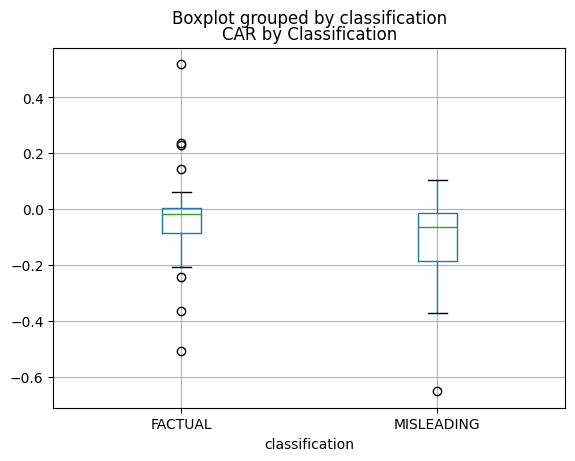

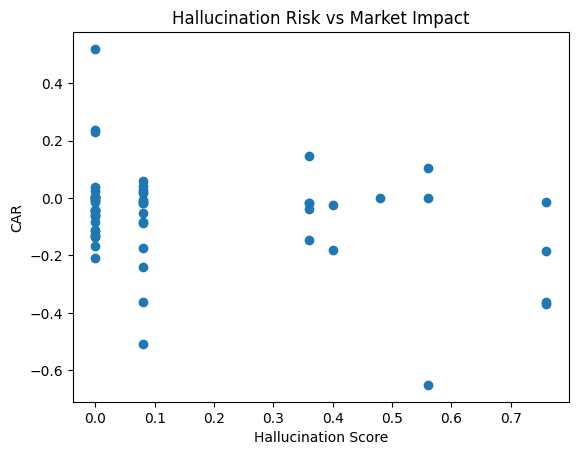

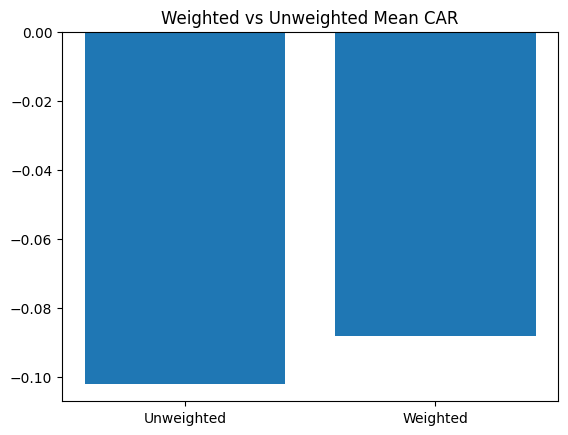

In [41]:
# Plot 1
import matplotlib.pyplot as plt
plt.figure()
df_layer3.boxplot(column='CAR', by='classification')
plt.title('CAR by Classification')
plt.savefig('car_by_classification.png')
plt.show()

# Plot 2
plt.figure()
plt.scatter(df_layer3['hallucination_score'], df_layer3['CAR'])
plt.xlabel('Hallucination Score')
plt.ylabel('CAR')
plt.title('Hallucination Risk vs Market Impact')
plt.savefig('hallucination_vs_car.png')
plt.show()

# Plot 3
plt.figure()
plt.bar(['Unweighted', 'Weighted'], [unweighted_CAR, weighted_CAR])
plt.title('Weighted vs Unweighted Mean CAR')
plt.savefig('weighted_comparison.png')
plt.show()